In [15]:
import numpy as np 
import scipy as sp 

import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.pyplot as plt
%matplotlib inline 

import pandas as pd 
from sklearn.model_selection import train_test_split

pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)

import seaborn as sns
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell


InteractiveShell.ast_node_interactivity = "all"

In [16]:
# Leer dataset proveniente del csv
vg_data = pd.read_csv("../dato.csv")

print('_'*40)

#Leer ultimos datos del dataset
vg_data.tail()

print('_'*40)

#Leer info general del dataset
vg_data.info()

print('_'*40)

#Leer cuantos datos hay en cada columna
vg_data.count()

print('_'*40)

________________________________________


,Platform,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Rating,Critic_Score_Class
7107,PC,Action,Ubisoft,0,0,0,0,"0,01",T,Excelente
7108,PC,Shooter,Midway Games,0,0,0,0,"0,01",T,Aceptable
7109,PC,Sports,Sega,0,0,0,0,"0,01",E,Aceptable
7110,PC,Strategy,Take-Two Interactive,0,0,0,0,"0,01",E10+,Aceptable
7111,PS4,Platform,Team Meat,0,0,0,0,"0,01",T,Excelente


________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Platform            7112 non-null   object
 1   Genre               7112 non-null   object
 2   Publisher           7112 non-null   object
 3   NA_Sales            7112 non-null   object
 4   EU_Sales            7112 non-null   object
 5   JP_Sales            7112 non-null   object
 6   Other_Sales         7112 non-null   object
 7   Global_Sales        7112 non-null   object
 8   Rating              7112 non-null   object
 9   Critic_Score_Class  7112 non-null   object
dtypes: object(10)
memory usage: 555.8+ KB
________________________________________


Platform              7112
Genre                 7112
Publisher             7112
NA_Sales              7112
EU_Sales              7112
JP_Sales              7112
Other_Sales           7112
Global_Sales          7112
Rating                7112
Critic_Score_Class    7112
dtype: int64

________________________________________


In [17]:
# Eliminar filas con valores nulos o vacios para evitar errores de entrenamiento
vg_data = vg_data.dropna()

# Reemplazar coma por punto
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(str).str.replace(",", ".")
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(str).str.replace(",", ".")
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(str).str.replace(",", ".")
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(str).str.replace(",", ".")
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(str).str.replace(",", ".")

# Convertir a float
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(float)
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(float)
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(float)
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(float)
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(float)


In [18]:

# Convertir Critic_Score_Class a valores numéricos
label_encoder = LabelEncoder()

vg_data["Critic_Score_Class"] = label_encoder.fit_transform(
    vg_data["Critic_Score_Class"]
)

# Definir parametros de entrenamiento y prueba
X = vg_data[["Platform", "Genre", "Publisher", "Rating"]]

# Definir variables objetivo
y = vg_data[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
]

In [19]:
# Separar dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Escalamiento de variables objetivo
scaler = StandardScaler()

# Escalar las variables objetivo de entrenamiento y prueba
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [28]:
# Tabla con cantidad de datos
tabla_procesamiento = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Cantidad de datos": [len(X_train), len(X_test)]
})

print(tabla_procesamiento)


        Conjunto  Cantidad de datos
0  Entrenamiento               5689
1         Prueba               1423


([<matplotlib.patches.Wedge at 0x25f6bf7f590>,
 [Text(-0.8897472497379938, 0.6467996842792028, 'Entrenamiento'),
  Text(0.8897471891802327, -0.6467997675833499, 'Prueba')],
 [Text(-0.4853166816752693, 0.352799827788656, '80.0%'),
  Text(0.4853166486437632, -0.35279987322728174, '20.0%')])

Text(0.5, 1.0, 'Separación del Dataset')

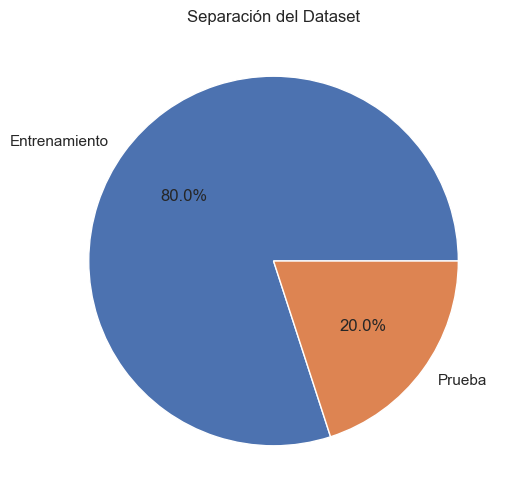

In [30]:
#Gráfica de pastel para mostrar la separación del dataset
fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    [len(X_train), len(X_test)],
    labels=["Entrenamiento", "Prueba"],
    autopct='%1.1f%%'
)

ax.set_title("Separación del Dataset")

plt.show()

Text(0.5, 1.0, 'Antes del Escalamiento')

[Text(1, 0, 'NA'),
 Text(2, 0, 'EU'),
 Text(3, 0, 'JP'),
 Text(4, 0, 'Other'),
 Text(5, 0, 'Global'),
 Text(6, 0, 'Critics')]

Text(0.5, 1.0, 'Después del Escalamiento')

[Text(1, 0, 'NA'),
 Text(2, 0, 'EU'),
 Text(3, 0, 'JP'),
 Text(4, 0, 'Other'),
 Text(5, 0, 'Global'),
 Text(6, 0, 'Critics')]

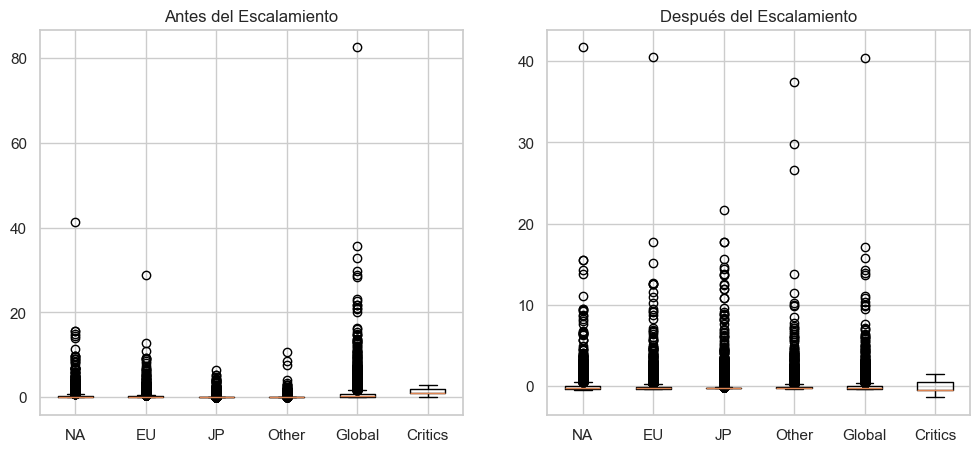

In [32]:
# Convertir arrays escalados a DataFrame
y_train_scaled_df = pd.DataFrame(
    y_train,
    columns=[
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score_Class"
    ]
)

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Antes del escalamiento
box1 = ax[0].boxplot(
    vg_data[
        [
            "NA_Sales",
            "EU_Sales",
            "JP_Sales",
            "Other_Sales",
            "Global_Sales",
            "Critic_Score_Class"
        ]
    ].values
)

ax[0].set_title("Antes del Escalamiento")

ax[0].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global",
    "Critics"
])

# Después del escalamiento
box2 = ax[1].boxplot(
    y_train_scaled_df[
        [
            "NA_Sales",
            "EU_Sales",
            "JP_Sales",
            "Other_Sales",
            "Global_Sales",
            "Critic_Score_Class"
        ]
    ].values
)

ax[1].set_title("Después del Escalamiento")

ax[1].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global",
    "Critics"
])

plt.show()